# Step 0 : Install and Load Libraries

In [ ]:
# !pip install PyPortfolioOpt
# !pip install arch

# Step 0 : Load Libraries

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis, linregress
# from pypfopt import expected_returns, risk_models, EfficientFrontier
# from arch.__future__ import reindexing
# from tqdm import tqdm

# Step 1 : Data Loading

In [ ]:
tickers = ['MSFT', 'TSCO.L', '^FTSE'] # your 2 tickers + market (Why : For comparison and for Calculating CAPM etc)

In [ ]:
data = yf.download(tickers, start='2024-05-05', end='2025-05-30')

/tmp/ipython-input-53-670881248.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start='2024-05-05', end='2025-05-30')
[*********************100%***********************]  3 of 3 completed


In [ ]:
data = data['Close']

# Step 2 : Data Exploration

In [ ]:
data.head()

Ticker,SBRY.L,TSCO.L,^FTSE
Date,,,
2024-05-07,267.575806,304.105591,8313.700195
2024-05-08,270.972992,307.603394,8354.099609
2024-05-09,273.970459,310.001892,8381.400391
2024-05-10,275.768921,311.500916,8433.799805
2024-05-13,278.766418,312.400299,8415.000000


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 269 entries, 2024-05-07 to 2025-05-29
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SBRY.L  269 non-null    float64
 1   TSCO.L  269 non-null    float64
 2   ^FTSE   269 non-null    float64
dtypes: float64(3)
memory usage: 8.4 KB


In [ ]:
data.describe()

Ticker,SBRY.L,TSCO.L,^FTSE
count,269.000000,269.000000,269.000000
mean,267.005047,348.985298,8353.214866
std,16.441425,25.222579,215.227851
min,228.721909,301.987213,7679.500000
25%,256.712341,327.016022,8205.099609
50%,266.908875,356.408478,8285.599609
75%,277.460785,368.562378,8520.500000
max,299.649628,396.898071,8871.299805


# Data Filtering

In [ ]:
data["MSFT"]

,SBRY.L
Date,
2024-05-07,267.575806
2024-05-08,270.972992
2024-05-09,273.970459
2024-05-10,275.768921
2024-05-13,278.766418
...,...
2025-05-22,286.702118
2025-05-23,287.501862
2025-05-27,292.899994


In [ ]:
data[data["MSFT"] > 280 ][["MSFT"]]

Ticker,SBRY.L
Date,
2024-05-16,281.963776
2024-05-17,283.362579
2024-05-20,284.361755
2024-05-21,283.162750
2024-05-22,283.162750
2024-08-15,281.058990
2024-08-16,280.459259
2024-08-19,284.057465
2024-08-22,283.057953


# Data Correlation

In [ ]:
data.corr()

Ticker,SBRY.L,TSCO.L,^FTSE
Ticker,,,
SBRY.L,1.000000,0.190201,-0.077315
TSCO.L,0.190201,1.000000,0.466896
^FTSE,-0.077315,0.466896,1.000000


# Returns Calculation

In [ ]:
returns = data.pct_change().dropna()

In [ ]:
returns.head()

Ticker,SBRY.L,TSCO.L,^FTSE
Date,,,
2024-05-08,0.012696,0.011502,0.004859
2024-05-09,0.011062,0.007797,0.003268
2024-05-10,0.006564,0.004836,0.006252
2024-05-13,0.010870,0.002887,-0.002229
2024-05-14,-0.001434,0.004159,0.001557


Excess Return

In [ ]:
rf_annual = 0.04
rf_daily = rf_annual / 252

In [ ]:
returns['SBRY_excess'] = returns['MSFT'] - rf_daily
returns['TSCO_excess'] = returns['TSCO.L'] - rf_daily
returns['Market_excess'] = returns['^FTSE'] - rf_daily

In [ ]:
returns.tail()

Ticker,SBRY.L,TSCO.L,^FTSE,SBRY_excess,TSCO_excess,Market_excess
Date,,,,,,
2025-05-22,-0.004167,0.002365,-0.005372,-0.004325,0.002206,-0.005531
2025-05-23,0.002789,0.000524,-0.002437,0.002631,0.000366,-0.002596
2025-05-27,0.018776,0.013361,0.006894,0.018617,0.013202,0.006735
2025-05-28,-0.030717,-0.003619,-0.005935,-0.030875,-0.003778,-0.006094
2025-05-29,-0.004930,-0.007525,-0.001089,-0.005088,-0.007683,-0.001247


In [ ]:
returns.describe()

Ticker,SBRY.L,TSCO.L,^FTSE,SBRY_excess,TSCO_excess,Market_excess
count,268.000000,268.000000,268.000000,268.000000,268.000000,268.000000
mean,0.000312,0.000945,0.000208,0.000154,0.000786,0.000049
std,0.014780,0.013272,0.007868,0.014780,0.013272,0.007868
min,-0.077708,-0.086945,-0.049524,-0.077867,-0.087103,-0.049683
25%,-0.006606,-0.005119,-0.003271,-0.006764,-0.005278,-0.003429
50%,0.000800,0.000890,0.000488,0.000641,0.000731,0.000329
75%,0.010131,0.007288,0.004664,0.009972,0.007129,0.004506
max,0.040309,0.043793,0.030445,0.040150,0.043635,0.030286




# Volatility (Risk)

In [ ]:
expected_return = returns[['MSFT', 'TSCO.L']].mean() * 252
volatility = returns[['MSFT', 'TSCO.L']].std() * np.sqrt(252)

In [ ]:
expected_return

,0
Ticker,
SBRY.L,0.078723
TSCO.L,0.238136


In [ ]:
volatility

,0
Ticker,
SBRY.L,0.234623
TSCO.L,0.210686


# Beta - Sensitivity to Market

In [ ]:
beta_sbry = linregress(returns['Market_excess'], returns['SBRY_excess'])[0]
beta_tsco = linregress(returns['Market_excess'], returns['TSCO_excess'])[0]

In [ ]:
beta_sbry

np.float64(0.3812718472127351)

In [ ]:
beta_tsco

np.float64(0.35738288111554)

# Max Drawdown

In [ ]:
cumulative = (1 + returns[['MSFT', 'TSCO.L']]).cumprod()
drawdown = cumulative / cumulative.cummax() - 1
mdd_sbry = drawdown['MSFT'].min()
mdd_tsco = drawdown['TSCO.L'].min()
print("Max Drawdown (SBRY):", round(mdd_sbry, 4))
print("Max Drawdown (TSCO):", round(mdd_tsco, 4))

Max Drawdown (SBRY): -0.2367
Max Drawdown (TSCO): -0.2076


# Value at Risk

In [ ]:
var_95 = returns[['MSFT', 'TSCO.L']].quantile(0.05)
var_99 = returns[['MSFT', 'TSCO.L']].quantile(0.01)

In [ ]:
print(var_95)
print(var_99)

Ticker
SBRY.L   -0.023189
TSCO.L   -0.016813
Name: 0.05, dtype: float64
Ticker
SBRY.L   -0.041563
TSCO.L   -0.040014
Name: 0.01, dtype: float64


# CAPM

In [ ]:
rm_annual = returns['^FTSE'].mean() * 252
capm_sbry = rf_annual + beta_sbry * (rm_annual - rf_annual)
capm_tsco = rf_annual + beta_tsco * (rm_annual - rf_annual)


In [ ]:
capm_sbry

np.float64(0.04469774591427016)

In [ ]:
capm_tsco

np.float64(0.044403403980294055)

# Sharpe Ratio

In [ ]:
"""# Sharpe Ratio"""

# Sharpe Ratio = (Expected Return - Risk-Free Rate) / Volatility
sharpe_sbry = (expected_return['MSFT'] - rf_annual) / volatility['MSFT']
sharpe_tsco = (expected_return['TSCO.L'] - rf_annual) / volatility['TSCO.L']

print("Sharpe Ratio (MSFT):", round(sharpe_sbry, 4))
print("Sharpe Ratio (TSCO.L):", round(sharpe_tsco, 4))

Sharpe Ratio (SBRY.L): 0.165
Sharpe Ratio (TSCO.L): 0.9404



# Monte Carlo Simulation

In [ ]:
assets = ['MSFT', 'TSCO.L'] # from my total assets, define which is my portfolio
cov = returns[assets].cov() * 252 # covariance
init_guess = [0.5, 0.5] # statrt with initial guess : 50% each
rf = 0.0419 # FRED Data

In [ ]:
# Assumes: assets, expected_return, cov, rf_annual already defined

n_sim = 1000
results = []
weights_record = []

for _ in range(n_sim): # Step 3 : Repeat 1000 times
    w = np.random.dirichlet(np.ones(len(assets))) + np.random.uniform(-1, 1) / len(assets) # Step 1
    w /= np.sum(w)
    if np.all((-1 <= w) & (w <= 1)):
        # Step 2 : Calculations
        ret = np.dot(w, expected_return[assets]) # Portfolio Expected Return
        vol = np.sqrt(np.dot(w, np.dot(cov, w))) # Portfolio Volatility
        sharpe = (ret - rf_annual) / vol # Portfolio Sharpe Ratio

        results.append([ret, vol, sharpe])
        weights_record.append(w)

results_df = pd.DataFrame(results, columns=["Return", "Volatility", "Sharpe"])
weights_df = pd.DataFrame(weights_record, columns=[f"Weight_{a}" for a in assets])
full_results = pd.concat([results_df, weights_df], axis=1)


 Best Sharpe:
 Return           0.237451
Volatility       0.210450
Sharpe           0.938233
Weight_SBRY.L    0.004302
Weight_TSCO.L    0.995698
Name: 495, dtype: float64

 Worst Sharpe:
 Return           0.079443
Volatility       0.234194
Sharpe           0.168422
Weight_SBRY.L    0.995480
Weight_TSCO.L    0.004520
Name: 451, dtype: float64

 Lowest Risk:
 Return           0.183615
Volatility       0.200973
Sharpe           0.714597
Weight_SBRY.L    0.342014
Weight_TSCO.L    0.657986
Name: 299, dtype: float64


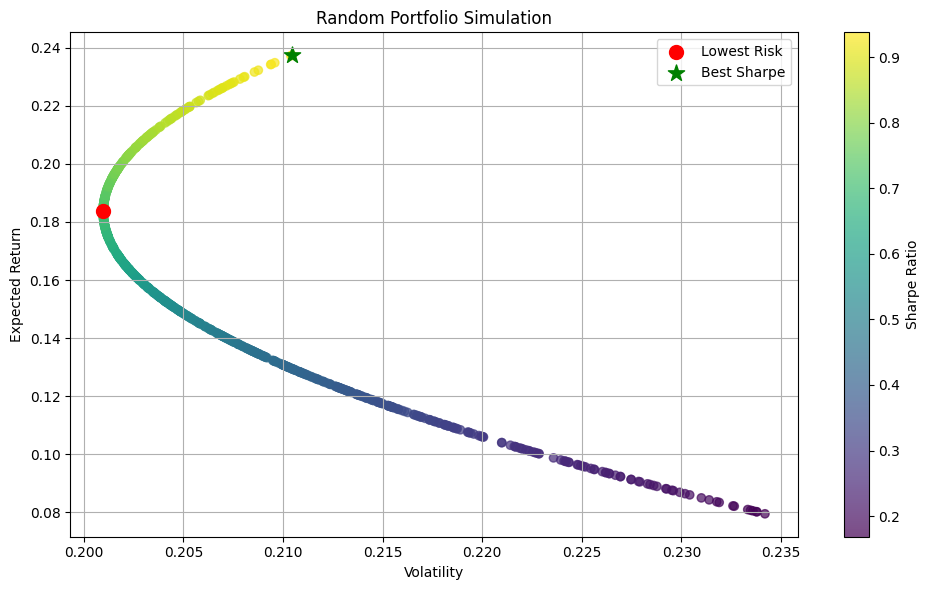

In [ ]:
best = results_df['Sharpe'].idxmax()
worst = results_df['Sharpe'].idxmin()
min_vol = results_df['Volatility'].idxmin()

print("\n Best Sharpe:\n", full_results.loc[best])
print("\n Worst Sharpe:\n", full_results.loc[worst])
print("\n Lowest Risk:\n", full_results.loc[min_vol])


# Below is visualization plots
plt.figure(figsize=(10, 6))
plt.scatter(results_df['Volatility'], results_df['Return'], c=results_df['Sharpe'], cmap='viridis', alpha=0.7)
plt.colorbar(label='Sharpe Ratio')
plt.scatter(*results_df.loc[min_vol, ['Volatility', 'Return']], c='red', s=100, label='Lowest Risk')
plt.scatter(*results_df.loc[best, ['Volatility', 'Return']], c='green', s=150, marker='*', label='Best Sharpe')
plt.title("Random Portfolio Simulation")
plt.xlabel("Volatility"), plt.ylabel("Expected Return")
plt.legend(), plt.grid(True), plt.tight_layout()
plt.show()


# Portfolio Optimization

# A. Long way

1. Mean Variance Portfolio

In [ ]:
from scipy.optimize import minimize

assets = ['MSFT', 'TSCO.L']
cov = returns[assets].cov() * 252
init_guess = [0.5, 0.5]

# Allow short selling: no bounds or bounds like (-1, 1)
bounds = [(-1, 1)] * len(assets)  # or use bounds = None for full flexibility
constraints = {'type': 'eq', 'fun': lambda w: sum(w) - 1}

In [ ]:
# Define portfolio volatility function (match your usage)
def port_vol(w):
    return np.sqrt(np.dot(w, np.dot(cov.loc[assets, assets], w)))

# === Minimum Variance Portfolio (analytical, like R) ===
inv_cov = np.linalg.inv(cov.loc[assets, assets])
ones = np.ones(len(assets))
w_mvp = inv_cov @ ones
w_mvp = w_mvp / np.sum(w_mvp)

ret_mvp = np.dot(w_mvp, expected_return[assets])
vol_mvp = port_vol(w_mvp)


In [ ]:
print(w_mvp)
print(ret_mvp)
print(vol_mvp)
print()

[0.34309668 0.65690332]
0.18344224059085484
0.20097309597631866



2. Max Sharpe Ratio Portfolio

In [ ]:
def neg_sharpe(w):
    ret = np.dot(w, expected_return[assets])
    vol = np.sqrt(np.dot(w, np.dot(cov, w)))
    return -(ret - rf_annual) / vol

sharpe = minimize(neg_sharpe, init_guess, bounds=bounds, constraints=constraints)
w_sharpe = sharpe.x
ret_sharpe = np.dot(w_sharpe, expected_return[assets])
vol_sharpe = port_vol(w_sharpe)
sharpe_ratio = (ret_sharpe - rf_annual) / vol_sharpe


In [ ]:
print(w_sharpe)
print(ret_sharpe)
print(vol_sharpe)
print(sharpe_ratio)

[-3.74700271e-16  1.00000000e+00]
0.23813646826756968
0.2106861712976831
0.940434139778535


# B. Short Way

In [ ]:
!pip install PyPortfolioOpt

In [ ]:
from pypfopt import EfficientFrontier, risk_models, expected_returns

In [ ]:
# Reformat data for PyPortfolioOpt
mu = expected_return[assets] # expected return
S = cov.loc[assets, assets] # covariance

Mean Variance Portfolio

In [ ]:
# PyPortfolioOpt Efficient Frontier (allows short selling)
ef = EfficientFrontier(mu, S, weight_bounds=(-1, 1))
# Minimum Variance Portfolio
w_pypfopt_mvp = ef.min_volatility()
cleaned_mvp = ef.clean_weights()

ret_pypfopt_mvp, vol_pypfopt_mvp, sharpe_pypfopt_mvp = ef.portfolio_performance()

In [ ]:
print(cleaned_mvp)
print(ret_pypfopt_mvp)
print(vol_pypfopt_mvp)

OrderedDict([('SBRY.L', 0.3431), ('TSCO.L', 0.6569)])
0.18344224059085495
0.2009730959763187


Max Sharpe Ratio Portfolio

In [ ]:
ef_msr = EfficientFrontier(mu, S, weight_bounds=(-1, 1))
# Maximum Sharpe Ratio
w_pypfopt_msr = ef_msr.max_sharpe()
cleaned_msr = ef_msr.clean_weights()

ret_pypfopt_msr, vol_pypfopt_msr, sharpe_pypfopt_msr = ef_msr.portfolio_performance()

In [ ]:
print(cleaned_msr)
print(ret_pypfopt_msr)
print(vol_pypfopt_msr)

OrderedDict([('SBRY.L', 0.0), ('TSCO.L', 1.0)])
0.2381364682675697
0.21068617129768316


# Post Optimization Monte Carlo

In [ ]:
def simulate_portfolio_growth(weights, label, n_simulations=1000, n_days=252, initial_investment=1000):
    mu_daily = returns[assets].mean()
    sigma_daily = returns[assets].std()

    simulated_paths = np.zeros((n_days, n_simulations))

    for i in range(n_simulations):
        asset_prices = np.ones((n_days, len(assets)))
        for j, asset in enumerate(assets):
            rand_returns = np.random.normal(mu_daily[asset], sigma_daily[asset], n_days)
            asset_prices[:, j] = np.cumprod(1 + rand_returns)
        simulated_paths[:, i] = initial_investment * np.dot(asset_prices, weights)

    final_values = simulated_paths[-1, :]

    # Print summary
    print(f"\n📊 {label} Portfolio Summary (Final Value after 1 Year):")
    print(f"Mean: £{final_values.mean():.2f}")
    print(f"Median: £{np.median(final_values):.2f}")
    print(f"5th Percentile (VaR): £{np.percentile(final_values, 5):.2f}")
    print(f"95th Percentile: £{np.percentile(final_values, 95):.2f}")

    return simulated_paths, final_values


In [ ]:
paths_mvp, finals_mvp = simulate_portfolio_growth(w_mvp, label="Minimum Variance")
paths_sharpe, finals_sharpe = simulate_portfolio_growth(w_sharpe, label="Max Sharpe Ratio")


📊 Minimum Variance Portfolio Summary (Final Value after 1 Year):
Mean: £1198.41
Median: £1176.55
5th Percentile (VaR): £914.66
95th Percentile: £1533.14

📊 Max Sharpe Ratio Portfolio Summary (Final Value after 1 Year):
Mean: £1265.20
Median: £1237.63
5th Percentile (VaR): £854.95
95th Percentile: £1772.39


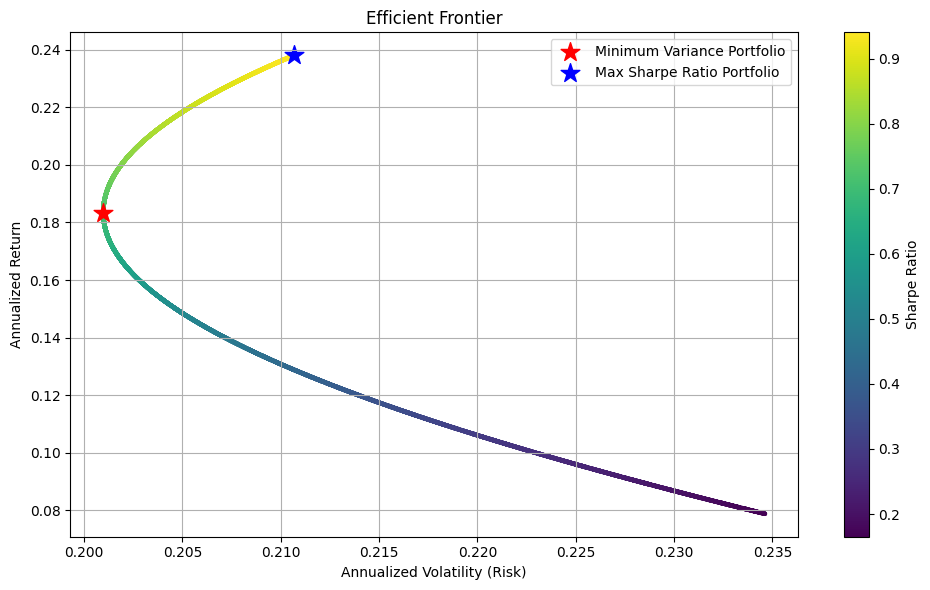

In [ ]:
# Parameters
n_portfolios = 10000
np.random.seed(42)

# Generate random weights (no short selling)
random_weights = np.random.dirichlet(np.ones(len(assets)), size=n_portfolios)

# Portfolio statistics
portfolio_returns = []
portfolio_volatilities = []
sharpe_ratios = []

for w in random_weights:
    ret = np.dot(w, expected_return[assets])
    vol = np.sqrt(np.dot(w.T, np.dot(cov, w)))
    sharpe = (ret - rf_annual) / vol

    portfolio_returns.append(ret)
    portfolio_volatilities.append(vol)
    sharpe_ratios.append(sharpe)

portfolio_returns = np.array(portfolio_returns)
portfolio_volatilities = np.array(portfolio_volatilities)
sharpe_ratios = np.array(sharpe_ratios)

# === Plot Efficient Frontier ===
plt.figure(figsize=(10, 6))
plt.scatter(portfolio_volatilities, portfolio_returns, c=sharpe_ratios, cmap='viridis', s=5)
plt.colorbar(label='Sharpe Ratio')

# Highlight MVP and Max Sharpe points
plt.scatter(vol_mvp, ret_mvp, color='red', marker='*', s=200, label='Minimum Variance Portfolio')
plt.scatter(vol_sharpe, ret_sharpe, color='blue', marker='*', s=200, label='Max Sharpe Ratio Portfolio')

# Labels
plt.title('Efficient Frontier')
plt.xlabel('Annualized Volatility (Risk)')
plt.ylabel('Annualized Return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Report Output

In [ ]:
# Step: Export All Metrics to CSV

# Create comprehensive results dataframe
results_summary = pd.DataFrame()

# Individual stock metrics
individual_metrics = pd.DataFrame({
    'Expected_Return': [expected_return['MSFT'], expected_return['TSCO.L']],
    'Volatility': [volatility['MSFT'], volatility['TSCO.L']]
    # 'Beta': [beta_sbry, beta_tsco],
    # 'Max_Drawdown': [mdd_sbry, mdd_tsco],
    # 'VaR_95': [var_95['MSFT'], var_95['TSCO.L']],
    # 'VaR_99': [var_99['MSFT'], var_99['TSCO.L']],
    # 'CAPM_Expected_Return': [capm_sbry, capm_tsco],
    # 'Sharpe_Ratio': [sharpe_sbry, sharpe_tsco]
}, index=['MSFT', 'TSCO.L'])

# Portfolio optimization results
portfolio_results = pd.DataFrame({
    'Weight_SBRY': [
        full_results.loc[min_vol, 'Weight_MSFT'],  # Monte Carlo Min Vol
        full_results.loc[best, 'Weight_MSFT'],  # Monte Carlo Best Sharpe
        cleaned_mvp['MSFT'],  # PyPortfolioOpt MVP
        cleaned_msr['MSFT']  # PyPortfolioOpt Max Sharpe
    ],
    'Weight_TSCO': [
        full_results.loc[min_vol, 'Weight_TSCO.L'],
        full_results.loc[best, 'Weight_TSCO.L'],
        cleaned_mvp['TSCO.L'],
        cleaned_msr['TSCO.L']
    ],
    'Expected_Return': [
        full_results.loc[min_vol, 'Return'],
        full_results.loc[best, 'Return'],
        ret_pypfopt_mvp,
        ret_pypfopt_msr
    ],
    'Volatility': [
        full_results.loc[min_vol, 'Volatility'],
        full_results.loc[best, 'Volatility'],
        vol_pypfopt_mvp,
        vol_pypfopt_msr
    ],
    'Sharpe_Ratio': [
        full_results.loc[min_vol, 'Sharpe'],
        full_results.loc[best, 'Sharpe'],
        sharpe_pypfopt_mvp,
        sharpe_pypfopt_msr
    ]
}, index=[
    'MonteCarlo_MinVol',
    'MonteCarlo_BestSharpe',
    'PyPortfolioOpt_MVP',
    'PyPortfolioOpt_MaxSharpe'
])

# Export to CSV files
individual_metrics.to_csv('individual_stock_metrics.csv')
full_results.to_csv('monte_carlo_simulation_results.csv')
portfolio_results.to_csv('portfolio_optimization_results.csv')


print("Data exported to CSV files:")
print("1. individual_stock_metrics.csv - Individual stock analysis")
print("2. portfolio_optimization_results.csv - Portfolio optimization comparison")
print("3. monte_carlo_simulation_results.csv - Full Monte Carlo simulation results")

# Display summary tables
print("\n=== INDIVIDUAL STOCK METRICS ===")
print(individual_metrics.round(4))

print("\n=== PORTFOLIO OPTIMIZATION RESULTS ===")
print(portfolio_results.round(4))

Data exported to CSV files:
1. individual_stock_metrics.csv - Individual stock analysis
2. portfolio_optimization_results.csv - Portfolio optimization comparison
3. monte_carlo_simulation_results.csv - Full Monte Carlo simulation results

=== INDIVIDUAL STOCK METRICS ===
        Expected_Return  Volatility
SBRY.L           0.0787      0.2346
TSCO.L           0.2381      0.2107

=== PORTFOLIO OPTIMIZATION RESULTS ===
                          Weight_SBRY  Weight_TSCO  Expected_Return  \
MonteCarlo_MinVol              0.3420       0.6580           0.1836   
MonteCarlo_BestSharpe          0.0043       0.9957           0.2375   
PyPortfolioOpt_MVP             0.3431       0.6569           0.1834   
PyPortfolioOpt_MaxSharpe       0.0000       1.0000           0.2381   

                          Volatility  Sharpe_Ratio  
MonteCarlo_MinVol             0.2010        0.7146  
MonteCarlo_BestSharpe         0.2104        0.9382  
PyPortfolioOpt_MVP            0.2010        0.9128  
PyPortfolioO